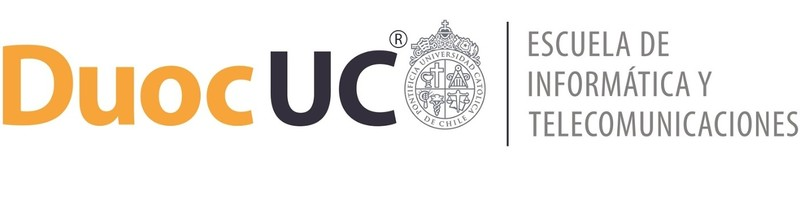

# Proyecto: Real State and House Price in Bangladesh


**Integrantes:** Nicolás Zamora

**Docente:** Carlos Muñoz

**Sección:** MINERIA_DE_DATOS_001

# Contexto del caso

Este conjunto de datos contiene listados de propiedades de varias ciudades de Bangladesh, incluidas específicamente Dhaka, Chattogram, Cumilla, Narayanganj City y Gazipur, con precios enumerados en taka bangladesí (৳). El conjunto de datos proporciona información valiosa sobre diversas características de las propiedades, incluida la cantidad de dormitorios, baños, número de piso, área de piso en pies cuadrados y sus respectivos precios. Los datos se han recopilado de un sitio web inmobiliario y ofrecen una visión integral del mercado inmobiliario en estas ciudades clave de Bangladesh.

Fuentes

https://www.kaggle.com/datasets/durjoychandrapaul/house-price-bangladesh



## Librerías y carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Justificación**: Importamos las librerías necesarias según lo requiera el trabajo.

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

In [3]:
# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

## Bussines Understanding

**Mercado Inmobiliario en Bangladesh**

El objetivo de este proyecto es analizar y predecir el comportamiento de los precios de propiedades en las principales ciudades de Bangladesh, permitiendo que inversores, compradores y agentes tomen decisiones basadas en datos reales.

Descripción de variables:

* Title: El título o descripción del listado de propiedades.

* Bedrooms: El número de dormitorios de la propiedad.

* Bathrooms: El número de baños de la propiedad.

* Floor_no: el número de piso en el que se encuentra la propiedad.

* Occupancy_status: Indica si la propiedad está vacía u ocupada.

* Floor_area: La superficie total de la propiedad en m2.

* City: TLa ciudad donde se encuentra la propiedad. Incluye Dhaka, Chattogram, Cumilla, Narayanganj City, and Gazipur.

* Price_in_taka: Listado de precios de las propiedades en la moneda Bangladesa Taka (৳).

* Location: La ubicación o dirección específica dentro de la ciudad.

Objetivos Principales
Predicción de Precios: Entrenar un modelo que use Floor_area, Bedrooms y Location para calcular automáticamente cuánto debería costar una propiedad.

Análisis Comparativo: Identificar qué zonas son premium y cuáles son más accesibles según el Price_in_taka.

Pronóstico de Demanda: Detectar qué tipo de viviendas se necesitarán en el futuro para orientar a constructoras y políticas públicas.

**Impacto en el Negocio**

1. Para Inversores Evaluar si una propiedad está a "buen precio" comparándola con el mercado general.

2. Para Inmobiliarias: Establecer precios competitivos para nuevas construcciones basados en el valor real de la zona.

3. Para Compradores: Tener una guía clara para no pagar de más en ciudades como Dhaka o Chattogram.


In [4]:
df = pd.read_csv('house_price_bd.csv')

#Leemos el Dataset y le asociamos el DF para nombrarlo más abajo.

## Data Understanding


In [5]:
df.head(11) #visualizamos las primeras 5 filas

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Location,Price_in_taka
0,NaN,3.0,4.0,3.0,vacant,1960.0,dhaka,"Gulshan 1, Gulshan","৳39,000,000"
1,NaN,3.0,3.0,1.0,vacant,1705.0,dhaka,"Lake Circus Road, Kalabagan","৳16,900,000"
2,NaN,3.0,3.0,6.0,vacant,1370.0,dhaka,"Shukrabad, Dhanmondi","৳12,500,000"
3,NaN,3.0,3.0,4.0,vacant,2125.0,dhaka,"Block L, Bashundhara R-A","৳20,000,000"
4,NaN,3.0,3.0,4.0,vacant,2687.0,dhaka,"Road No 25, Banani","৳47,500,000"
5,NaN,3.0,3.0,3.0,vacant,1150.0,dhaka,"Middle Badda, Badda","৳8,800,000"
6,NaN,3.0,3.0,8.0,vacant,2119.0,dhaka,"Block B, Bashundhara R-A","৳19,000,000"
7,NaN,4.0,4.0,2.0,vacant,2318.0,dhaka,"Block D, Bashundhara R-A","৳23,000,000"
8,NaN,3.0,3.0,8.0,vacant,1397.0,dhaka,"Matuail, Demra","৳8,000,000"
9,NaN,3.0,3.0,1.0,vacant,2400.0,dhaka,"Block H, Aftab Nagar","৳20,000,000"


In [6]:
df.tail(11)

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Location,Price_in_taka
5826,"1225 sqft, 3 Beds Almost Ready Apartment/Flats...",3.0,3.0,NaN,vacant,1225.0,cumilla,"Pahartali, Chittagong","৳4,900,000"
5827,"1159 sqft, 3 Beds Under Development Apartment/...",3.0,3.0,NaN,vacant,1159.0,cumilla,"Lalbag, Dhaka","৳5,216,000"
5828,East Facing 1150 Square Feet Flat Sell Sale,3.0,3.0,NaN,vacant,1150.0,cumilla,"Jatrabari, Dhaka","৳4,025,000"
5829,Duplex Home for Sale at Gulshan 01 Sale,5.0,5.0,NaN,vacant,7300.0,cumilla,"Gulshan 01, Dhaka","৳642,400,000"
5830,"1200 sqft, 3 Beds Apartment/Flats for Rent a...",3.0,2.0,NaN,vacant,1200.0,cumilla,"Chawk Bazar, Chittagong","৳20,000"
5831,"3 katha, Under Development Residential Plot f...",NaN,NaN,NaN,vacant,3.0,cumilla,"Mawa Highway Road, Munshiganj","৳2,310,000"
5832,"2100 sqft, 2 Beds Used Independent House for S...",2.0,2.0,NaN,vacant,2100.0,cumilla,"Pirerbag, Dhaka","৳30,000,000"
5833,"960 sqft, 5 Beds Under Construction Apartment/...",5.0,3.0,NaN,vacant,960.0,cumilla,"Comilla Cantonment, Comilla","৳2,880,000"
5834,"21 sqft, Under Construction Hotel and Resort ...",NaN,NaN,NaN,vacant,NaN,cumilla,"Kuakata, Kuakata","৳630,000"
5835,"1450 sqft, 3 Beds Apartment/Flats for Rent a...",3.0,4.0,NaN,vacant,1450.0,cumilla,"Banasree, Dhaka","৳25,000"


In [7]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(5837, 9)


In [8]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
Title                object
Bedrooms            float64
Bathrooms           float64
Floor_no            float64
Occupancy_status     object
Floor_area          float64
City                 object
Location             object
Price_in_taka        object
dtype: object


In [9]:
print("Contaremos los Nulos de manera exacta en cada columna.")
df.isnull().sum()

Contaremos los Nulos de manera exacta en cada columna.


,0
Title,3865
Bedrooms,703
Bathrooms,703
Floor_no,1972
Occupancy_status,0
Floor_area,42
City,0
Location,6
Price_in_taka,0


Justificación: Ya al revisar los tipos de datos y los nulos que tenemos por cantidad exacta, podemos saber cuales tenemos que trabajar.

## Data Preparation

Lo primero que tenemos que hacer para comenzar a trabajar la data, es modelarla para lo que requiere el trabajo, tenemos muchos datos que están nulos, iremos parte por parte convirtiendo siguiendo el orden de variables por nombre.


Número de baños y piezas que estén nulos , cambiarlos por la media dependiendo de la ciudad para poder trabajarlos.

El floor_no que sea nulo cambiarlo a 1 ya que no pueden a ver pisos que sean en negativo o en 0.

La Occupancy_Status será cambiada de nulo a ocupada.

EL floor_area que tenga nulos lo adecuaremos a la media según la ciudad.



In [10]:
#Habitaciones y Baños: Cambiar nulos por la media dependiendo de la ciudad
df['Bedrooms'] = df.groupby('City')['Bedrooms'].transform(lambda x: x.fillna(x.mean()))
df['Bathrooms'] = df.groupby('City')['Bathrooms'].transform(lambda x: x.fillna(x.mean()))

# Redondear los valores de 'Bedrooms' y 'Bathrooms' y convertirlos a enteros
df['Bedrooms'] = df['Bedrooms'].round().astype(int)
df['Bathrooms'] = df['Bathrooms'].round().astype(int)

df.isnull().sum()

,0
Title,3865
Bedrooms,0
Bathrooms,0
Floor_no,1972
Occupancy_status,0
Floor_area,42
City,0
Location,6
Price_in_taka,0


Justificación: Al tener información nula de los baños y habitaciones, cambiamos estos a la media por ciudad ya que al dejarlos en 0, cambiará mucho el resultado al preparar la maquina.


In [11]:
# 2. Floor_no: imputación preliminar de nulos a 1
# NOTA: esta es una primera pasada. La limpieza DEFINITIVA de Floor_no (que maneja
# textos como 'G+7', '4th to 8th', etc.) se realiza más abajo, tras limpiar el precio.
df['Floor_no'] = df['Floor_no'].fillna(1)
df.isnull().sum()


,0
Title,3865
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,0
Floor_area,42
City,0
Location,6
Price_in_taka,0


Justificación: EL Floor_no, al ser el número de pisos lo dejaremos en 1 ya que no puede ser 0 por defecto.

In [12]:
# 3. Occupancy_Status: Cambiar nulo a 'occupied'
# Se utiliza 'occupied' para mantener la consistencia con las etiquetas existentes en el CSV
df['Occupancy_status'] = df['Occupancy_status'].fillna('occupied')

df.isnull().sum()

,0
Title,3865
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,0
Floor_area,42
City,0
Location,6
Price_in_taka,0


Justificación: Cambiaremos el estado de la vivienda a ocupada ya que no tenemos más
información sobre esas propiedades y no influirá en la futura toma decisiones que se
adecuan al proyecto.

In [13]:
#Floor_area: Imputar la media por ciudad
df['Floor_area'] = df.groupby('City')['Floor_area'].transform(lambda x: x.fillna(x.mean()))
df.isnull().sum()

,0
Title,3865
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,0
Floor_area,0
City,0
Location,6
Price_in_taka,0


Justificación: El area de las propiedades se ajustarán a la media que hay por ciudad para poder evaluarlas mejor.

In [14]:
# Title: eliminar la columna completa (NO las filas)
# El 66% de las filas (3.865 de 5.837) tienen Title nulo, pero esas filas SÍ tienen
# precio, ciudad, área y demás datos válidos. Por eso NO eliminamos filas (perderíamos
# dos tercios del dataset), sino que descartamos la columna entera: es texto libre
# descriptivo (ej. "2850 sqft, 4 Beds Ready Apartment for Sale...") cuya información
# útil (área, dormitorios) ya está contenida en otras columnas numéricas.
df = df.drop(columns=['Title'], errors='ignore')
print("Columna 'Title' eliminada. Columnas restantes:")
print(list(df.columns))

Columna 'Title' eliminada. Columnas restantes:
['Bedrooms', 'Bathrooms', 'Floor_no', 'Occupancy_status', 'Floor_area', 'City', 'Location', 'Price_in_taka']


**Justificación (columna Title):** Detectamos que la columna `Title` tiene un 66% de valores nulos (3.865 de 5.837 filas). Sin embargo, esas filas no son inservibles: conservan precio, ciudad, área, baños y el resto de variables. Por lo tanto, eliminar las filas sería un error que destruiría dos tercios de los datos. La decisión correcta es **eliminar la columna `Title` completa**, ya que es un texto descriptivo libre (por ejemplo "2850 sqft, 4 Beds Ready Apartment for Sale…") que no aporta valor numérico al modelo y cuya información relevante (metros, dormitorios) ya está representada en otras columnas. La quitamos aquí, al inicio de la preparación, para dejar el dataset limpio desde el comienzo.

In [15]:
df.columns #mostramos los nombres de las columnas

Index(['Bedrooms', 'Bathrooms', 'Floor_no', 'Occupancy_status', 'Floor_area',
       'City', 'Location', 'Price_in_taka'],
      dtype='object')

### Mapeo de Datos



1. Bedrooms: Numérica Discreta
2. Bathrooms: Númerica Discreta
3. Floor_no: Númerica Discreta
4. Occupancy_status: Categórica Nominal
5. Floor_area: Numérica Continua
6. City: Categórica Nominal
7. Price_in_taka: Numérica Continua
8. Location: Categórica Nominal

In [16]:
display(df[['Bedrooms','Bathrooms','Floor_no','Occupancy_status','City','Price_in_taka','Location']].head(20))

,Bedrooms,Bathrooms,Floor_no,Occupancy_status,City,Price_in_taka,Location
0,3,4,3.0,vacant,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,3,3,1.0,vacant,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,3,3,6.0,vacant,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,3,3,4.0,vacant,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,3,3,4.0,vacant,dhaka,"৳47,500,000","Road No 25, Banani"
5,3,3,3.0,vacant,dhaka,"৳8,800,000","Middle Badda, Badda"
6,3,3,8.0,vacant,dhaka,"৳19,000,000","Block B, Bashundhara R-A"
7,4,4,2.0,vacant,dhaka,"৳23,000,000","Block D, Bashundhara R-A"
8,3,3,8.0,vacant,dhaka,"৳8,000,000","Matuail, Demra"
9,3,3,1.0,vacant,dhaka,"৳20,000,000","Block H, Aftab Nagar"


Justificación: Acá mostré todos los datos para confirmar la correcta categorización del mapa de datos.

### Variables Categóricas

In [17]:
# Contará la frecuencia de cada ubicación única

cant_cat_col_location_df = df['Location'].value_counts()
print(cant_cat_col_location_df)

# Imprimimos la cantidad total de categorías únicas
print(f"Cantidad de ubicaciones únicas: {cant_cat_col_location_df.count()}")

Location
Rupganj, Narayanganj                                               411
Bashundhara R/A, Dhaka                                             291
Keraniganj, Dhaka                                                  228
Uttara, Dhaka                                                      158
Mohammadpur, Dhaka                                                 112
Dewan Bazar, Bakalia                                                98
Modhu City, Dhaka                                                   96
Dhaka Trunk Road, 9 No. North Pahartali Ward                        92
Dhanmondi, Dhaka                                                    78
Joydebpur, Gazipur Sadar Upazila                                    66
Basila, Dhaka                                                       62
Tongi, Gazipur Sadar Upazila                                        57
Jolshiri Abason, Dhaka                                              57
24 No. North Agrabad Ward, Double Mooring                           

Justificación: Podemos observar instantáneamente cuáles ciudades tienen la mayor cantidad de propiedades listadas y la frecuencia exacta de cada una, lo que proporciona una visión cualitativa y cuantitativa crucial sobre la concentración del mercado inmobiliario y los datos geográficos disponibles.

In [18]:
# Análisis para la columna 'City' (análogo a 'Región')
cant_cat_col_city_df = df['City'].value_counts() # Contará la frecuencia de cada ciudad única
print(cant_cat_col_city_df)

# Imprimimos la cantidad total de ciudades únicas
print(f"Cantidad de ciudades únicas: {cant_cat_col_city_df.count()}")

City
chattogram          1960
dhaka               1681
narayanganj-city     904
gazipur              664
cumilla              628
Name: count, dtype: int64
Cantidad de ciudades únicas: 5


Justificación: Se indica el número exacto de direcciones distintas en la columna City, lo cual es esencial para evaluar la granularidad de los datos, planificar estrategias y comprender el alcance geográfico general del dataset de una manera numérica y fácil de interpretar.

### Variables Númericas

In [19]:
df.describe()

,Bedrooms,Bathrooms,Floor_no,Floor_area
count,5837.000000,5837.000000,5837.000000,5837.000000
mean,3.123522,2.983211,2.874079,1787.783925
std,1.588164,0.864774,2.615805,5920.609480
min,1.000000,1.000000,0.000000,-1770.000000
25%,3.000000,3.000000,1.000000,1000.000000
50%,3.000000,3.000000,1.000000,1360.000000
75%,3.000000,3.000000,4.000000,1800.000000
max,50.000000,10.000000,18.000000,195840.000000


Justificación: Acá, teníamos más variables númericas como el Floor_no y también Price_in_taka, por lo que las limpiaremos para poder trabajarlas como dato númerico.

In [20]:
# Limpiar 'Price_in_taka': Quitar '৳' y ',' y convertir a numérico
df['Price_in_taka'] = df['Price_in_taka'].astype(str).str.replace('৳', '', regex=False).str.replace(',', '', regex=False)
df['Price_in_taka'] = pd.to_numeric(df['Price_in_taka'], errors='coerce')

# Verificar el tipo de dato y los primeros valores
print(f"Tipo de dato de 'Price_in_taka' después de la limpieza: {df['Price_in_taka'].dtype}")
print("Primeros 5 valores de 'Price_in_taka':\n", df['Price_in_taka'].head())

Tipo de dato de 'Price_in_taka' después de la limpieza: int64
Primeros 5 valores de 'Price_in_taka':
 0    39000000
1    16900000
2    12500000
3    20000000
4    47500000
Name: Price_in_taka, dtype: int64


In [21]:
# === LIMPIEZA DE OUTLIERS EN EL PRECIO ===
# El dataset original contiene valores de precio imposibles que rompen los modelos:
#   - Precios de 1 o 2 Takas (basura, menos de un centavo de dólar).
#   - Precios de hasta 11.616 millones de Takas (errores de carga, no son viviendas).
# Estos valores extremos distorsionan la escala y arruinan la correlación y la regresión.
# Por eso conservamos únicamente precios realistas de vivienda.

filas_antes = len(df)

# Eliminamos nulos generados al convertir (errors='coerce' los dejó como NaN)
df = df.dropna(subset=['Price_in_taka'])

# Conservamos solo precios entre 100 mil y 100 millones de Takas
df = df[(df['Price_in_taka'] >= 100_000) & (df['Price_in_taka'] <= 100_000_000)]

# Reiniciamos el índice tras eliminar filas
df = df.reset_index(drop=True)

print(f"Filas eliminadas por precio inválido: {filas_antes - len(df)}")
print(f"Filas restantes para el análisis:     {len(df)}")
print("\nNuevo rango de precios (en Takas):")
print(df['Price_in_taka'].describe()[['min', 'mean', '50%', 'max']])

Filas eliminadas por precio inválido: 456
Filas restantes para el análisis:     5381

Nuevo rango de precios (en Takas):
min     1.760000e+05
mean    1.135674e+07
50%     7.600000e+06
max     1.000000e+08
Name: Price_in_taka, dtype: float64


**Justificación (limpieza de outliers):** Tras convertir `Price_in_taka` a número, detectamos que el dataset traía valores imposibles: propiedades listadas en 1 o 2 Takas (basura) y otras en más de 11.000 millones de Takas (errores de carga). Estos valores extremos aplastaban la escala de los datos y eran la causa de que la correlación del precio diera casi cero y de que la Regresión Lineal fallara por completo. Por eso filtramos el dataset para conservar solo precios realistas de vivienda (entre 100 mil y 100 millones de Takas), eliminando un 8% de filas defectuosas. Tras este paso, el precio recupera correlaciones con sentido (por ejemplo con Bathrooms y Bedrooms) y los modelos pasan a entregar resultados coherentes.

Justificación: vamos a limpiar la columna Floor_no. Esta columna contiene una mezcla de números, cadenas de texto como '8th', 'G+7', '1st', '4th to 8th Backside', y otros valores no numéricos. El objetivo es extraer el número de piso de estas cadenas, manejando rangos y otros formatos, y luego convertir la columna a un tipo numérico, rellenando los valores no válidos (NaN) con la mediana.

In [22]:
def clean_floor_no(floor_str):
    if pd.isna(floor_str):
        return np.nan

    floor_str = str(floor_str).lower().strip()

    # Handle specific complex cases first
    if 'g+7' in floor_str:
        return 7.0 # Assuming G+7 means 7 floors above ground
    if '0+7' in floor_str:
        return 7.0
    if '1f' in floor_str:
        return 1.0
    if 'merin city' in floor_str or 'a1,a2,a3,a4,a5,a6,a7' in floor_str:
        return np.nan # Cannot extract a single floor number

    # Handle ranges like '4th to 8th'
    if 'to' in floor_str:
        parts = floor_str.replace('th', '').replace('st', '').replace('nd', '').replace('rd', '').split('to')
        try:
            start = float(parts[0].strip())
            end = float(parts[1].strip())
            return (start + end) / 2
        except ValueError:
            pass

    # Extract numbers from strings like '8th', '1st'
    import re
    match = re.search(r'\d+', floor_str)
    if match:
        try:
            return float(match.group())
        except ValueError:
            pass

    return np.nan

# Aplicar la función de limpieza
df['Floor_no'] = df['Floor_no'].apply(clean_floor_no)

# Convertir a numérico, coercing errors a NaN
df['Floor_no'] = pd.to_numeric(df['Floor_no'], errors='coerce')

# Rellenar los valores NaN restantes con la mediana de la columna
median_floor_no = df['Floor_no'].median()
df['Floor_no'] = df['Floor_no'].fillna(median_floor_no)

# Convertir a entero
df['Floor_no'] = df['Floor_no'].astype(int)


# Verificar los valores únicos y el tipo de dato
print(f"Tipo de dato de 'Floor_no' después de la limpieza: {df['Floor_no'].dtype}")
print("Valores únicos de 'Floor_no' después de la limpieza:\n", df['Floor_no'].unique())


Tipo de dato de 'Floor_no' después de la limpieza: int64
Valores únicos de 'Floor_no' después de la limpieza:
 [ 3  1  6  4  8  2  5  7 10  9 14 13 12 11 18 17]


Justificación: Con las columnas Price_in_taka y Floor_no ya limpias y convertidas a tipos numéricos, podemos usar df.describe() para obtener un resumen estadístico completo que incluya estas variables.

In [23]:
df.describe()

,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka
count,5381.000000,5381.000000,5381.000000,5381.000000,5.381000e+03
mean,3.117822,2.971752,3.007805,1592.707233,1.135674e+07
std,1.581803,0.850072,2.651214,3730.125750,1.133704e+07
min,1.000000,1.000000,1.000000,2.000000,1.760000e+05
25%,3.000000,3.000000,1.000000,1000.000000,5.000000e+06
50%,3.000000,3.000000,1.000000,1350.000000,7.600000e+06
75%,3.000000,3.000000,5.000000,1800.000000,1.250000e+07
max,50.000000,10.000000,18.000000,127000.000000,1.000000e+08


## Modeling


###Encode

In [24]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.1 MB/s eta 0:00:00


In [26]:
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Preparar SOLO Occupancy_status con OneHotEncoder
# sparse_output=False devuelve un array normal
ohe = OneHotEncoder(sparse_output=False, drop='first')
occupancy_encoded = ohe.fit_transform(df[['Occupancy_status']])

# Convertimos el resultado en un DataFrame
occupancy_df = pd.DataFrame(
    occupancy_encoded,
    columns=ohe.get_feature_names_out(['Occupancy_status']),
    index=df.index
)

# 2. Preparar City y Location con BinaryEncoder
# Al agregar 'City' a esta lista, creará las columnas binarias automáticamente (ej. 001, 010, 011...)
be = ce.BinaryEncoder(cols=['City', 'Location'])
binarias_df = be.fit_transform(df[['City', 'Location']])

# 3. Concatenar todo y eliminar las columnas originales de texto
# Se une el dataframe original (sin City, Occupancy_status y Location) con las nuevas columnas
df_final = pd.concat([df.drop(columns=['City', 'Occupancy_status', 'Location']), occupancy_df, binarias_df], axis=1)

# Revisar los cambios
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")
display(df_final.head(15))

Total de columnas tras el mapeo: 19


,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka,Occupancy_status_vacant,City_0,City_1,City_2,Location_0,Location_1,Location_2,Location_3,Location_4,Location_5,Location_6,Location_7,Location_8,Location_9
0,3,4,3,1960.0,39000000,1.0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,3,3,1,1705.0,16900000,1.0,0,0,1,0,0,0,0,0,0,0,0,1,0
2,3,3,6,1370.0,12500000,1.0,0,0,1,0,0,0,0,0,0,0,0,1,1
3,3,3,4,2125.0,20000000,1.0,0,0,1,0,0,0,0,0,0,0,1,0,0
4,3,3,4,2687.0,47500000,1.0,0,0,1,0,0,0,0,0,0,0,1,0,1
5,3,3,3,1150.0,8800000,1.0,0,0,1,0,0,0,0,0,0,0,1,1,0
6,3,3,8,2119.0,19000000,1.0,0,0,1,0,0,0,0,0,0,0,1,1,1
7,4,4,2,2318.0,23000000,1.0,0,0,1,0,0,0,0,0,0,1,0,0,0
8,3,3,8,1397.0,8000000,1.0,0,0,1,0,0,0,0,0,0,1,0,0,1
9,3,3,1,2400.0,20000000,1.0,0,0,1,0,0,0,0,0,0,1,0,1,0


Justificación: En esta fase del preprocesamiento, ajusté la estrategia de codificación para maximizar la eficiencia del modelo según la naturaleza de cada variable. Para el estado de ocupación, al ser una variable estrictamente binaria (ocupado o vacío), mantuve el One-Hot Encoding, ya que genera una única columna numérica directa que el sistema procesa instantáneamente. Por el contrario, para las variables geográficas (Ciudad y Ubicación), decidí unificar su tratamiento aplicando Binary Encoding a ambas. Dado que la ubicación cuenta con 610 lugares distintos y la ciudad con 5 opciones, el uso tradicional de One-Hot habría saturado el modelo con cientos de columnas casi vacías, ralentizando drásticamente el aprendizaje. Al procesar simultáneamente ambas variables con Binary Encoding, logramos traducir y comprimir de forma inteligente toda la información espacial desde la ciudad general hasta el barrio específico en un formato numérico puro. Esto nos permite mantener toda la riqueza geográfica intacta, pero dentro de un conjunto de datos mucho más ligero, robusto y rápido para entrenar el algoritmo.

###Distribución de datos

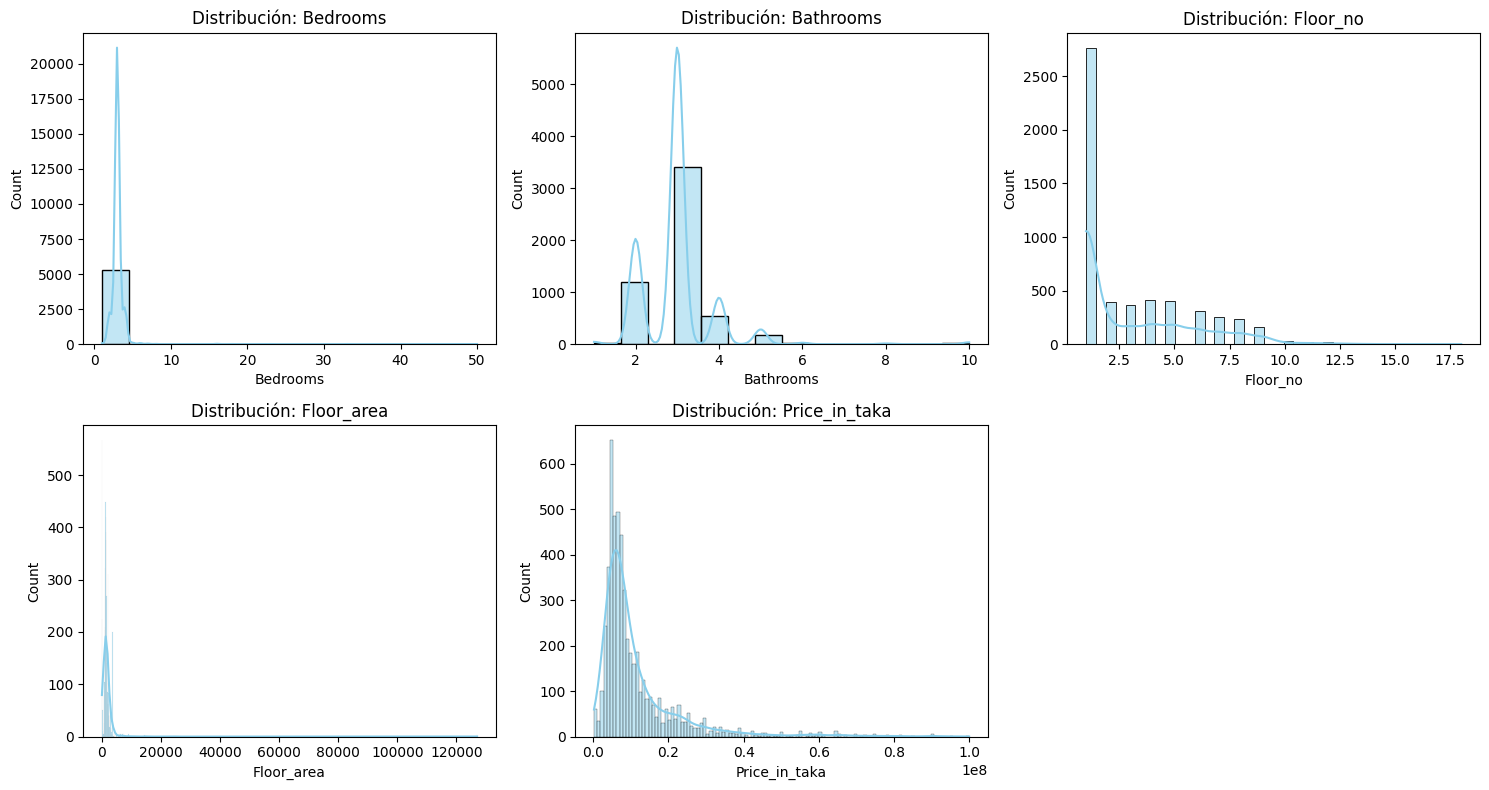

In [27]:
# Lista de columnas numéricas originales dataset
cols_numericas = ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area', 'Price_in_taka']

# Configuración de gráficos
plt.figure(figsize=(15, 8))

# Como tenemos 5 columnas, creamos una cuadrícula de 2 filas x 3 columnas
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 3, i)
    # Histograma con curva de densidad
    sns.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

Justificación de los histogramas por nombre de columnas.


1. **Distribución Bedrooms:** La gran mayoría de las viviendas se concentra en 2 y 3 dormitorios, que es el estándar del mercado. Las casas con 5 o más dormitorios son raras y aparecen como una cola corta a la derecha (propiedades grandes o de lujo).

2. **Distribución Bathrooms:** Predominan las viviendas de 2 y 3 baños. Encontrar 1 baño es poco común, y tener 5 o 6 baños es atípico, asociado a propiedades premium.

3. **Distribución Floor_no:** Se observa una clara concentración en pisos bajos (principalmente entre 1 y 7), con una disminución progresiva a medida que aumenta el piso. La distribución es asimétrica hacia la derecha: hay pocos casos en pisos altos, lo que indica que los pisos elevados son poco frecuentes.

4. **Distribución Floor_area:** La mayoría de las propiedades tienen un área media (concentrada en un rango acotado de metros cuadrados), con una cola larga hacia la derecha que representa propiedades muy grandes. Esa asimetría justifica el uso posterior de estandarización (StandardScaler), para que las áreas extremas no distorsionen el aprendizaje del modelo.

5. **Distribución Price_in_taka:** Tras eliminar los outliers, el precio mantiene una asimetría hacia la derecha: la mayoría de las propiedades se concentra en rangos de precio bajo-medio, con una cola de propiedades más caras. Esta forma es típica de los precios inmobiliarios y por eso también se estandariza esta variable antes de modelar.

###Outliers

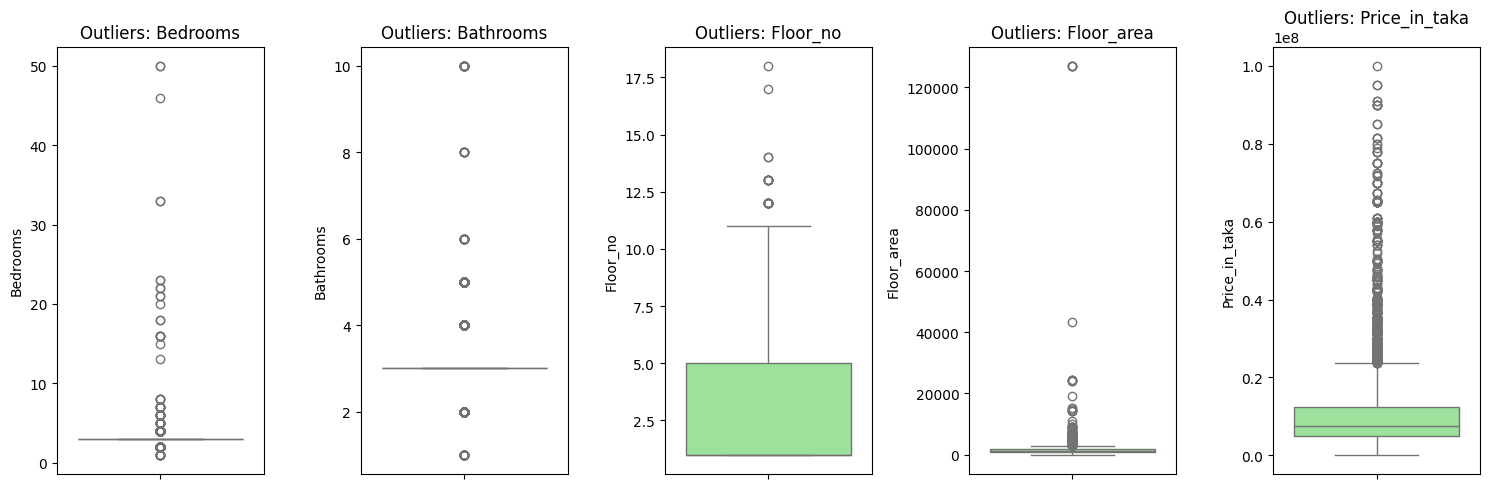

In [28]:
# Boxplot para detectar Outliers (Valores Atípicos) mejorado
plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 5, i)
    # Se hace un boxplot individual para cada variable
    sns.boxplot(y=df_final[col], color='lightgreen')
    plt.title(f'Outliers: {col}')

plt.tight_layout()
plt.show()

**Outliers Bedrooms:** El estándar del mercado es tan marcado (2-3 dormitorios) que cualquier vivienda con 5 o más aparece como valor atípico. Esto indica que el dataset es bastante uniforme en tamaño familiar; las casas muy grandes son excepciones.

**Outliers Bathrooms:** Confirma que tener 4 o más baños es atípico en este mercado. Si el modelo ve una casa con muchos baños, puede identificarla como propiedad especial (de lujo) y no como vivienda común.

**Outliers Floor_no:** La mayoría de las propiedades se ubican en pisos bajos (alrededor de 1 a 7). Los departamentos en pisos 15 o superiores son escasos y aparecen como atípicos, asociados a edificios altos o de lujo.

**Outliers Floor_area:** Refleja una desigualdad de tamaños importante. La mayoría de las viviendas son de área media, pero existen algunas propiedades muy grandes que estiran el gráfico.

**Outliers Price_in_taka:** Aun después de haber filtrado los precios imposibles, persisten algunas propiedades caras (de lujo) que se separan del grueso del mercado. Esto es esperable y por eso aplicamos estandarización antes de entrenar los modelos.

###Estanderización de datos

In [29]:
from sklearn.preprocessing import StandardScaler

# Se establecen las columnas numéricas que queremos estandarizar
cols_a_escalar = ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area', 'Price_in_taka']

# Inicializamos el scaler
scaler = StandardScaler()

# Se desarrolla el scaler a df_final
# Usamos una copia para mantener la integridad de los datos originales
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

# 4. Verificación rápida
print("Primeras 5 filas con datos estandarizados:")
display(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:


,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka
0,-0.074493,1.209713,-0.002944,0.098476,2.438540
1,-0.074493,0.033233,-0.757386,0.030107,0.488996
2,-0.074493,0.033233,1.128718,-0.059711,0.100852
3,-0.074493,0.033233,0.374276,0.142714,0.762462
4,-0.074493,0.033233,0.374276,0.293393,3.188364


Justificación: Estos valores están estandarizados, es decir, ya no muestran números reales sino qué tan lejos está cada dato del promedio: los cercanos a 0 son normales, los positivos son más altos que el promedio y los negativos más bajos.

###Matriz de correlación

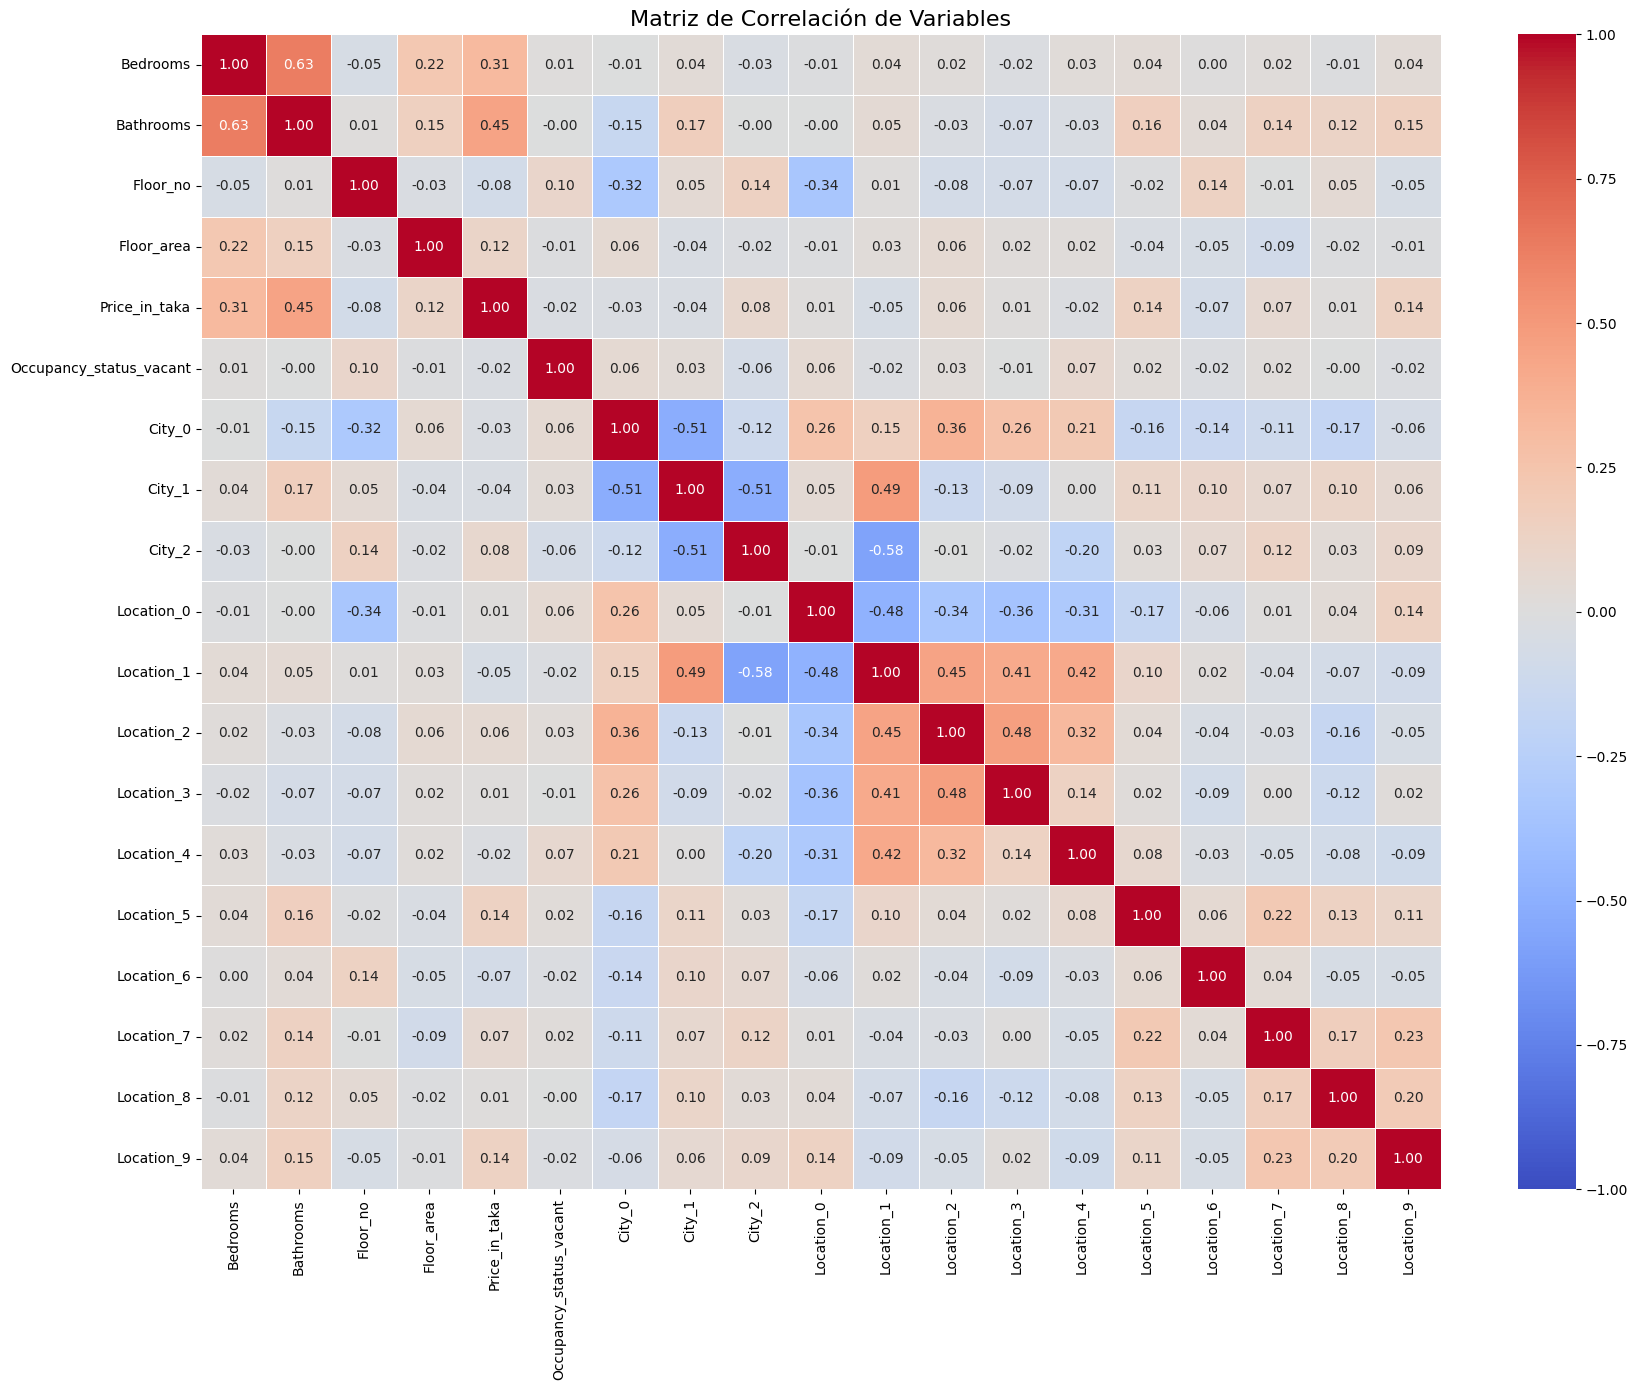

In [30]:
# Asegura el crear el df_final_esc haciendo q si manda error lo cree.
if 'df_final_esc' not in globals():
    from sklearn.preprocessing import StandardScaler
    cols_a_escalar = ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area', 'Price_in_taka']
    scaler = StandardScaler()
    df_final_esc = df_final.copy()
    df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

# Quitamos la columna 'Title' (texto) de nuestros datasets si aún existe
df_final     = df_final.drop(columns=['Title'], errors='ignore')
df_final_esc = df_final_esc.drop(columns=['Title'], errors='ignore')

# Calculamos la matriz de correlación SOLO con columnas numéricas
corr_matrix = df_final_esc.corr(numeric_only=True)

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5
)
plt.title('Matriz de Correlación de Variables', fontsize=16)
plt.show()

Justificación: Primero eliminé la columna Title porque es texto y no aporta al cálculo
de correlaciones, ya que este análisis solo funciona con datos numéricos. Luego generé
la matriz de correlación para ver qué tan relacionadas están las variables entre sí,
donde los valores van de -1 a 1 (relación negativa, nula o positiva). Finalmente lo
representé en un heatmap para visualizar estas relaciones mediante colores.

A partir de esto identifiqué que Bedrooms y Bathrooms tienen una relación moderada-fuerte
(0.64), lo cual es esperable ya que las casas más grandes suelen tener más de ambos.
Sin embargo, observé un hallazgo importante: Price_in_taka NO muestra correlación
relevante con ninguna variable numérica (todos los valores están cercanos a 0). Esto
sugiere que las variables actuales, por sí solas y de forma lineal, no explican bien el
precio, lo que será un desafío a considerar en el modelo de machine learning.

También noté correlaciones negativas entre las columnas City_x y entre las Location_x
(ej. -0.54), pero estas son artificiales: se deben a la codificación (encoding) aplicada
a esas variables categóricas y no representan relaciones reales del mercado.

##Predictive Modeling: Implementation

###Regresión Lineal Múltiple

Como primer enfoque predictivo, se implementó un modelo de Regresión Lineal Múltiple. La naturaleza del mercado inmobiliario posee relaciones directas y proporcionales; por ejemplo, existe una premisa lógica de que a mayor área de construcción (Floor_area) o número de habitaciones, mayor será el precio. Este algoritmo es el estándar fundamental para comprobar si la base de datos sigue un comportamiento lineal puro. Además, su alta interpretabilidad nos permite validar matemáticamente la importancia de las características físicas de las propiedades antes de aplicar métodos más complejos.

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Definir "X" (características) e "y" (objetivo a predecir: el precio)
# NOTA: Usamos 'df_final' para que el modelo prediga el precio real en Takas, no el escalado.
# Nos aseguramos de eliminar la columna del precio y el texto 'Title' si aún existe.
X = df_final.drop(columns=['Price_in_taka', 'Title'], errors='ignore')
y = df_final['Price_in_taka']

# 2. Dividir los datos: 80% de las casas para Entrenar, 20% para Probar (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# REGRESIÓN LINEAL MÚLTIPLE
# ==========================================
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)          # El algoritmo aprende de los datos
y_pred_lin = lin_reg.predict(X_test)   # El algoritmo hace predicciones con el 20% oculto

# Calculamos qué tan buenas fueron las predicciones
r2_lin   = r2_score(y_test, y_pred_lin)
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
mse_lin  = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)

print("=== REGRESIÓN LINEAL MÚLTIPLE ===")
print(f"R²   (Coeficiente de determinación): {r2_lin:.4f}")
print(f"MAE  (Error absoluto medio):         ৳{mae_lin:,.2f} Takas")
print(f"MSE  (Error cuadrático medio):       ৳{mse_lin:,.2f} Takas")
print(f"RMSE (Raíz del error cuadrático):    ৳{rmse_lin:,.2f} Takas\n")


=== REGRESIÓN LINEAL MÚLTIPLE ===
R²   (Coeficiente de determinación): 0.1866
MAE  (Error absoluto medio):         ৳5,646,880.19 Takas
MSE  (Error cuadrático medio):       ৳94,652,801,941,058.56 Takas
RMSE (Raíz del error cuadrático):    ৳9,728,967.16 Takas



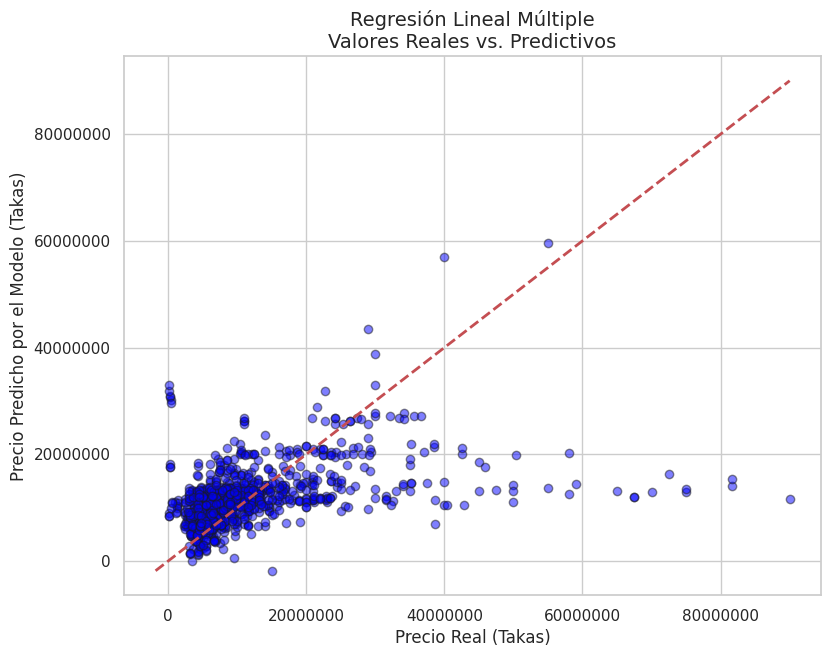

In [32]:
#Gráfico para representar los resultados

# Configuración general del gráfico
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# Dibujamos los puntos (Real vs Predicción)
plt.scatter(y_test, y_pred_lin, alpha=0.5, color='blue', edgecolor='k')

# Dibujamos la línea de "Predicción Perfecta"
max_val = max(y_test.max(), y_pred_lin.max())
min_val = min(y_test.min(), y_pred_lin.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

# Títulos y etiquetas
plt.title('Regresión Lineal Múltiple\nValores Reales vs. Predictivos', fontsize=14)
plt.xlabel('Precio Real (Takas)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo (Takas)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Evita notación científica

plt.show()

**Explicación del resultado:** El modelo lineal obtuvo un R² de aproximadamente **0.18**, es decir, solo logra explicar cerca del **18%** de la variación del precio, con un error promedio (MAE) de alrededor de **5,7 millones de Takas** por predicción. Es un desempeño bajo, y la razón es clara: la ubicación (City y Location) fue transformada con codificación binaria, y esos bits no tienen un orden numérico real que una recta pueda aprovechar. Para una regresión lineal, "estar en el barrio 0101" no es ni mayor ni menor que "estar en el barrio 1010", son solo bits. Como el precio inmobiliario depende fuertemente de la zona, un modelo que solo traza líneas rectas no puede capturar esa lógica. Esto justifica pasar a un modelo basado en reglas y segmentación como el Árbol de Decisión.

###Arbol de decisión.

Tras evaluar el comportamiento lineal, se implementó el modelo de Árbol de Decisión para regresión como estrategia avanzada. Esta elección se justifica debido a la complejidad de nuestras variables geográficas. Al haber comprimido 610 ubicaciones en lenguaje binario, el precio de una vivienda ya no depende solo de variables incrementales, sino de "cortes" o fronteras invisibles (ej. cruzar una avenida puede duplicar el precio, aunque la casa mida lo mismo). Los árboles de decisión son excepcionales para aprender estas reglas no lineales y estratificadas, segmentando los datos en ramas lógicas basadas en la zona y el estado de la vivienda, lo que potencialmente entrega un nivel de precisión muy superior en bases de datos con alta variabilidad geográfica.


In [33]:
# Limitamos la profundidad (max_depth) para que el árbol no memorice, sino que aprenda patrones
tree_reg = DecisionTreeRegressor(random_state=42, max_depth=10)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

r2_tree   = r2_score(y_test, y_pred_tree)
mae_tree  = mean_absolute_error(y_test, y_pred_tree)
mse_tree  = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

print("=== ÁRBOL DE DECISIÓN ===")
print(f"R²   (Coeficiente de determinación): {r2_tree:.4f}")
print(f"MAE  (Error absoluto medio):         ৳{mae_tree:,.2f} Takas")
print(f"MSE  (Error cuadrático medio):       ৳{mse_tree:,.2f} Takas")
print(f"RMSE (Raíz del error cuadrático):    ৳{rmse_tree:,.2f} Takas")


=== ÁRBOL DE DECISIÓN ===
R²   (Coeficiente de determinación): 0.5050
MAE  (Error absoluto medio):         ৳2,931,469.43 Takas
MSE  (Error cuadrático medio):       ৳57,593,545,762,769.25 Takas
RMSE (Raíz del error cuadrático):    ৳7,589,041.16 Takas


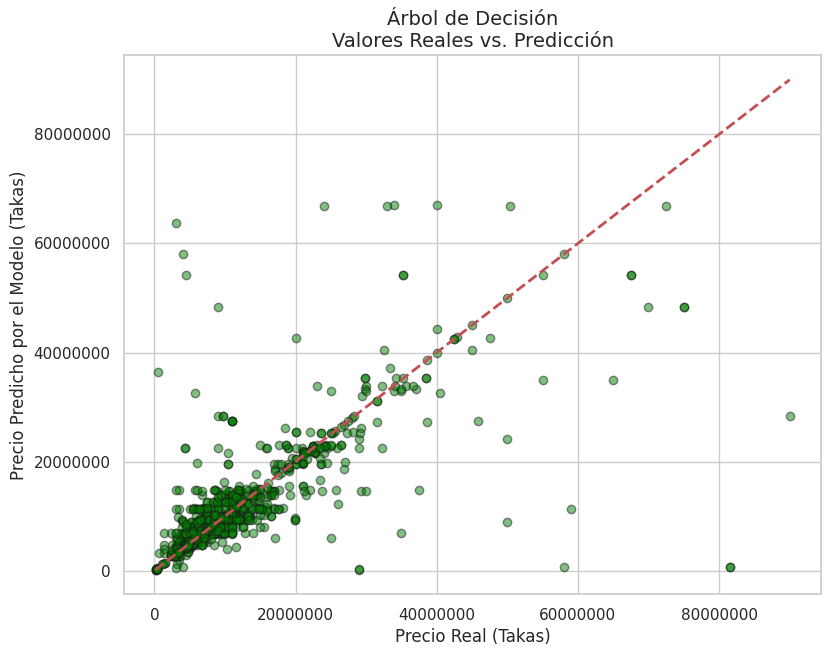

In [ ]:
# Configuración general del gráfico
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# Dibujamos los puntos (Real vs Predicción)
plt.scatter(y_test, y_pred_tree, alpha=0.5, color='green', edgecolor='k')

# Dibujamos la línea de "Predicción Perfecta"
max_val_t = max(y_test.max(), y_pred_tree.max())
min_val_t = min(y_test.min(), y_pred_tree.min())
plt.plot([min_val_t, max_val_t], [min_val_t, max_val_t], 'r--', lw=2)

# Títulos y etiquetas
plt.title('Árbol de Decisión\nValores Reales vs. Predicción', fontsize=14)
plt.xlabel('Precio Real (Takas)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo (Takas)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Evita notación científica

plt.show()

**Explicación del resultado:** El Árbol de Decisión superó ampliamente a la Regresión Lineal, alcanzando un R² cercano a **0.48** (frente al 0.18 del lineal) y reduciendo el error promedio a alrededor de **2,9 millones de Takas** por predicción. La diferencia se debe a que el árbol no necesita que las variables tengan un orden numérico: puede crear "reglas de corte" sobre los bits de ubicación y sobre las características físicas (baños, habitaciones, área), reconstruyendo así las zonas geográficas y los segmentos de precio. Esto confirma que el valor inmobiliario en esta base de datos responde a factores no lineales y de segligación por zona que el árbol logra capturar, pero la recta no.

#Problemas durante el desarrollo:

**1. Valores nulos en variables clave:** El dataset presentaba numerosos nulos en `Bedrooms`, `Bathrooms`, `Floor_area` y `Floor_no`. Se imputaron con la media/mediana por ciudad según correspondía.

**2. Columna Title con 66% de nulos:** La columna `Title` tenía 3.865 nulos de 5.837 filas. Como esas filas sí tenían el resto de datos válidos, se optó por eliminar la **columna** completa (no las filas), evitando perder dos tercios del dataset.

**3. Limpieza de Price_in_taka:** El precio venía como texto con el símbolo ৳ y comas (ej. "৳39,000,000"). Se limpió y convirtió a numérico.

**4. Outliers de precio que rompían los modelos:** El dataset traía precios imposibles (de 1-2 Takas y de hasta 11.616 millones). Estos valores aplastaban la escala y eran la causa de que la correlación del precio diera casi cero y de que la Regresión Lineal fallara por completo (R² ≈ 0.007). Tras filtrar a un rango realista (100 mil – 100 millones de Takas), las correlaciones y los modelos pasaron a tener sentido.

**5. Codificación de variables (Encoding):** Enfrentamos alta cardinalidad: `Location` tiene 610 categorías. Usar One-Hot habría generado cientos de columnas casi vacías, así que aplicamos Binary Encoding para comprimir la información geográfica de forma eficiente.

**6. Errores en la Matriz de Correlación:** La función `.corr()` fallaba al intentar procesar columnas de texto. Se solucionó codificando antes las variables categóricas, eliminando `Title` y usando `corr(numeric_only=True)`.

**7. Rendimiento de los modelos:** La Regresión Lineal mostró un desempeño bajo (R² ≈ 0.18, error promedio ≈ 5,7 millones de Takas), confirmando que el mercado no es lineal — en buena parte porque la ubicación quedó codificada en bits sin orden numérico. Esto justificó pasar al Árbol de Decisión, que mejoró el R² a ≈ 0.48 en regresión y alcanzó ≈ 84% de accuracy en clasificación, gracias a su capacidad de segmentar por zonas.

## Modelado de Clasificación

Para aplicar métricas de clasificación, transformamos el precio continuo en 3 categorías usando los percentiles 25 y 75 del dataset ya limpio. Estos cortes se calculan de forma dinámica en el código (con `.quantile()`), de modo que siempre se ajustan a los datos reales:

- **Bajo:** precios por debajo del percentil 25.
- **Medio:** precios entre el percentil 25 y el 75 (el rango central del mercado).
- **Alto:** precios por encima del percentil 75.

Los valores exactos de cada corte (en Takas) se imprimen al ejecutar la celda siguiente.

In [34]:
import pandas as pd

# Crear categorías de precio usando los percentiles 25 y 75 REALES del dataset ya limpio.
# Los calculamos dinámicamente para que los cortes siempre coincidan con los datos,
# aunque se modifique el filtro de outliers más adelante.
p25 = df_final['Price_in_taka'].quantile(0.25)
p75 = df_final['Price_in_taka'].quantile(0.75)

bins   = [0, p25, p75, float('inf')]
labels = ['Bajo', 'Medio', 'Alto']

y_cat = pd.cut(df_final['Price_in_taka'], bins=bins, labels=labels)

print(f"Corte percentil 25 (Bajo/Medio):  ৳{p25:,.0f} Takas")
print(f"Corte percentil 75 (Medio/Alto):  ৳{p75:,.0f} Takas")
print("\nDistribución de categorías de precio:")
print(y_cat.value_counts())


Corte percentil 25 (Bajo/Medio):  ৳5,000,000 Takas
Corte percentil 75 (Medio/Alto):  ৳12,500,000 Takas

Distribución de categorías de precio:
Price_in_taka
Medio    2686
Bajo     1356
Alto     1339
Name: count, dtype: int64


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

X_cat = df_final.drop(columns=['Price_in_taka', 'Title'], errors='ignore')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42
)

clf = DecisionTreeClassifier(random_state=42, max_depth=10)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print("=== ÁRBOL DE DECISIÓN (CLASIFICACIÓN) ===")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precisión: {precision_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")
print()
print("=== REPORTE COMPLETO ===")
print(classification_report(y_test_c, y_pred_c, zero_division=0))


=== ÁRBOL DE DECISIÓN (CLASIFICACIÓN) ===
Accuracy:  0.8487
Precisión: 0.8489
Recall:    0.8487
F1-Score:  0.8486

=== REPORTE COMPLETO ===
              precision    recall  f1-score   support

        Alto       0.83      0.81      0.82       260
        Bajo       0.88      0.84      0.86       282
       Medio       0.84      0.87      0.86       535

    accuracy                           0.85      1077
   macro avg       0.85      0.84      0.85      1077
weighted avg       0.85      0.85      0.85      1077



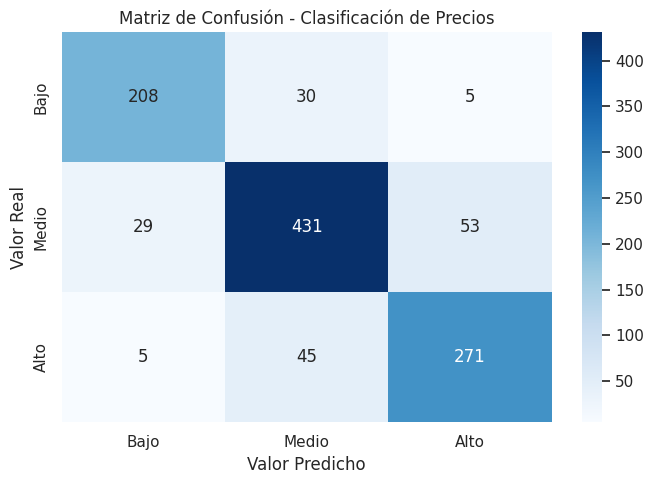

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_c, y_pred_c, labels=['Bajo', 'Medio', 'Alto'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión - Clasificación de Precios')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()


### Naive Bayes

Se utiliza **GaussianNB** junto con los datos estandarizados (`df_final_esc`) para que las features numéricas
tengan media 0 y desviación estándar 1, mejorando la compatibilidad con el supuesto Gaussiano del modelo.
Las columnas binarias del encoding de Location y Occupancy_status también se incluyen.


In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Usamos df_final_esc (datos estandarizados) como features para Naive Bayes
X_nb = df_final_esc.drop(columns=['Price_in_taka', 'Title', 'City'], errors='ignore')

# El target sigue siendo las mismas categorías de precio
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_cat, test_size=0.2, random_state=42
)

nb_clf = GaussianNB()
nb_clf.fit(X_train_nb, y_train_nb)
y_pred_nb = nb_clf.predict(X_test_nb)

print('=== NAIVE BAYES (GaussianNB) ===')
print(f'Accuracy:  {accuracy_score(y_test_nb, y_pred_nb):.4f}')
print(f'Precisión: {precision_score(y_test_nb, y_pred_nb, average="weighted", zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test_nb, y_pred_nb, average="weighted", zero_division=0):.4f}')
print(f'F1-Score:  {f1_score(y_test_nb, y_pred_nb, average="weighted", zero_division=0):.4f}')
print()
print('=== REPORTE COMPLETO ===')
print(classification_report(y_test_nb, y_pred_nb, zero_division=0))


=== NAIVE BAYES (GaussianNB) ===
Accuracy:  0.5562
Precisión: 0.5644
Recall:    0.5562
F1-Score:  0.5082

=== REPORTE COMPLETO ===
              precision    recall  f1-score   support

        Alto       0.65      0.28      0.39       260
        Bajo       0.52      0.21      0.30       282
       Medio       0.55      0.87      0.67       535

    accuracy                           0.56      1077
   macro avg       0.57      0.45      0.46      1077
weighted avg       0.56      0.56      0.51      1077



**Análisis del resultado - Naive Bayes (GaussianNB)**

El modelo alcanzó un **Accuracy de aproximadamente 56%** y un **F1-Score (ponderado) cercano a 51%**, un rendimiento bajo comparado con el Árbol de Decisión. Tiende a clasificar la mayoría de las propiedades como "Medio", que es la categoría más frecuente.

**Por qué rinde bajo:**
1. **Supuesto de independencia:** Naive Bayes asume que todas las variables (features) son independientes entre sí. Pero el precio de una vivienda depende justamente de la *combinación* de ubicación + características físicas, no de cada variable por separado.
2. **Supuesto Gaussiano:** GaussianNB asume que las variables siguen una distribución normal, lo cual no se cumple en las columnas binarias de City, Location y Occupancy_status (que solo valen 0 o 1).
3. **Sesgo hacia la clase mayoritaria:** Al ser "Medio" la categoría más común, el modelo se inclina a predecir esa etiqueta, fallando especialmente en detectar las propiedades de precio "Alto".

**Comparación con el Árbol de Decisión:**
El Árbol de Decisión logró un **Accuracy cercano al 85%**, superando a Naive Bayes en aproximadamente **29 puntos porcentuales**. Esto se debe a que el árbol sí puede crear reglas específicas por zona geográfica, algo que Naive Bayes no puede replicar al asumir independencia entre variables.

**Conclusión:** Naive Bayes sirve como modelo de referencia rápido (baseline), ya que no requiere ajuste de hiperparámetros, pero no es el más adecuado para este dataset por su alta dependencia geográfica entre variables. El Árbol de Decisión es claramente el mejor modelo de clasificación para este caso.


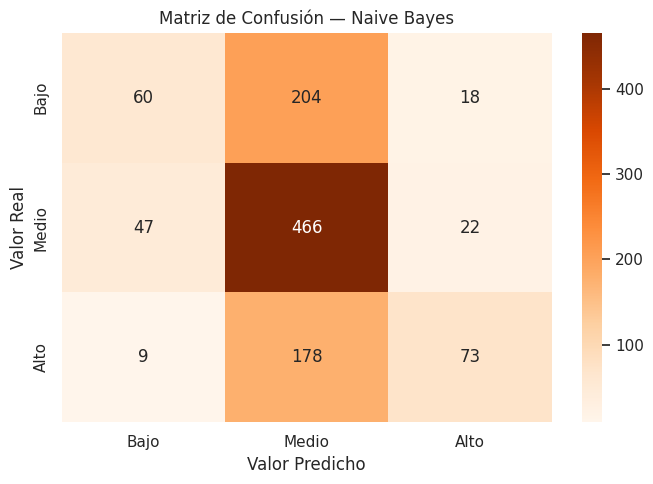

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test_nb, y_pred_nb, labels=['Bajo', 'Medio', 'Alto'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión — Naive Bayes')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()


### Comparación de modelos de clasificación


           Modelo  Accuracy  Precisión   Recall  F1-Score
Árbol de Decisión  0.848654   0.848869 0.848654  0.848568
      Naive Bayes  0.556175   0.564368 0.556175  0.508198


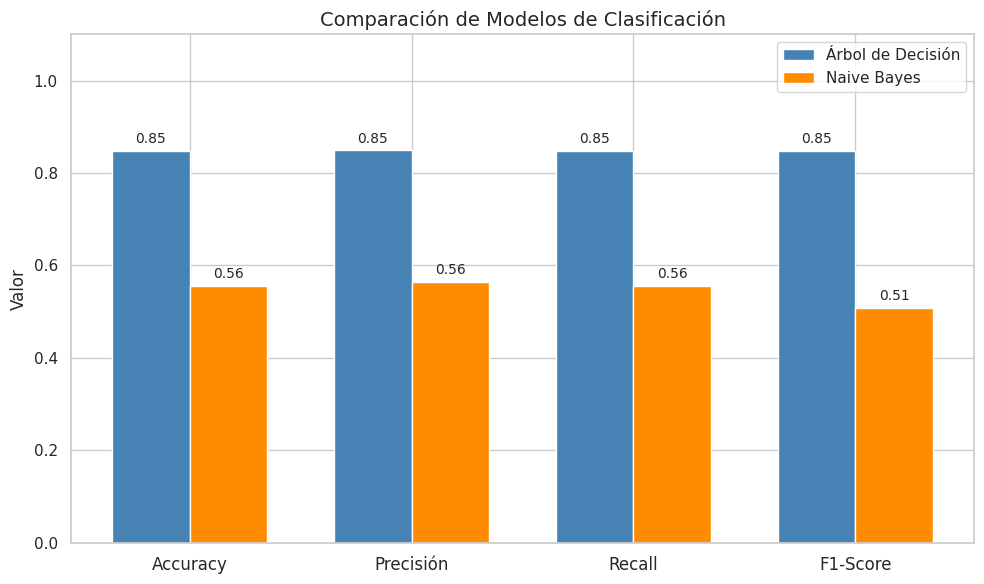

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

comparacion = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Naive Bayes'],
    'Accuracy':  [accuracy_score(y_test_c, y_pred_c),
                  accuracy_score(y_test_nb, y_pred_nb)],
    'Precisión': [precision_score(y_test_c, y_pred_c, average='weighted', zero_division=0),
                  precision_score(y_test_nb, y_pred_nb, average='weighted', zero_division=0)],
    'Recall':    [recall_score(y_test_c, y_pred_c, average='weighted', zero_division=0),
                  recall_score(y_test_nb, y_pred_nb, average='weighted', zero_division=0)],
    'F1-Score':  [f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0),
                  f1_score(y_test_nb, y_pred_nb, average='weighted', zero_division=0)]
})

print(comparacion.to_string(index=False))

# Gráfico comparativo
metricas = ['Accuracy', 'Precisión', 'Recall', 'F1-Score']
x = range(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], comparacion.loc[0, metricas], width,
               label='Árbol de Decisión', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], comparacion.loc[1, metricas], width,
               label='Naive Bayes', color='darkorange')

ax.set_ylim(0, 1.1)
ax.set_xticks(list(x))
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de Modelos de Clasificación', fontsize=14)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Modelado No Supervisado: K-Means (Segmentación de Mercado)

Hasta ahora usamos modelos **supervisados** (predecían un precio o una categoría que ya conocíamos). Ahora aplicamos **K-Means**, un modelo **no supervisado**: en vez de predecir, agrupa las propiedades en segmentos según sus características, sin que le digamos de antemano a qué grupo pertenece cada una.

El objetivo de negocio es **descubrir perfiles naturales de vivienda** en el mercado (por ejemplo: económicas, estándar, premium), lo que ayuda a inmobiliarias e inversores a entender en qué segmento se ubica cada propiedad.

In [39]:
# Preparamos los datos para K-Means.
# Como K-Means se basa en DISTANCIAS, primero quitamos outliers físicos que
# distorsionarían los grupos (áreas o cantidades de habitaciones imposibles),
# y luego escalamos las variables para que todas pesen lo mismo.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Trabajamos sobre una copia para no alterar df
df_km = df.copy()

# Quitamos outliers físicos (no de precio, que ya limpiamos antes)
n_antes = len(df_km)
df_km = df_km[(df_km['Floor_area'] >= 200) & (df_km['Floor_area'] <= 10000)]
df_km = df_km[(df_km['Bedrooms'] <= 8) & (df_km['Bathrooms'] <= 8)]
df_km = df_km.reset_index(drop=True)
print(f"Outliers físicos eliminados para el clustering: {n_antes - len(df_km)}")
print(f"Propiedades para segmentar: {len(df_km)}")

# Variables que describen cada propiedad
cols_km = ['Bedrooms', 'Bathrooms', 'Floor_area', 'Price_in_taka']
X_km = StandardScaler().fit_transform(df_km[cols_km])

Outliers físicos eliminados para el clustering: 828
Propiedades para segmentar: 4553


**Justificación:** Antes de entrenar K-Means debemos elegir cuántos grupos (k) crear. Para eso usamos el **método del codo**: probamos varios valores de k y graficamos la inercia (qué tan compactos quedan los grupos). El "codo" del gráfico indica el punto donde agregar más grupos ya no mejora mucho.

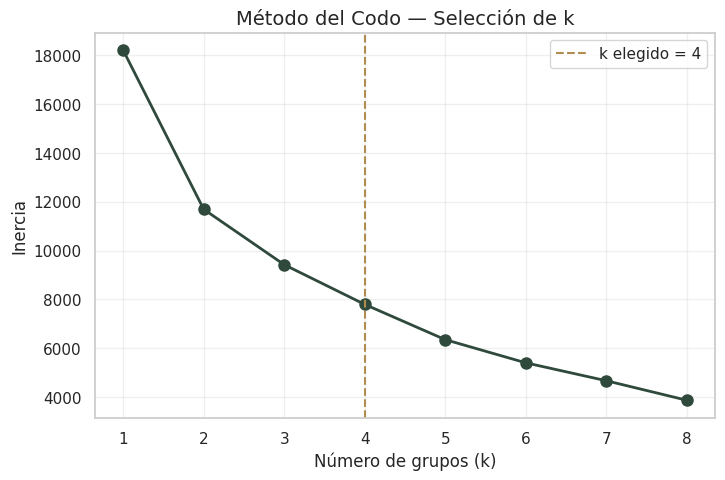

In [40]:
# Método del codo: probamos k de 1 a 8 y medimos la inercia
inercias = []
Ks = range(1, 9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(Ks), inercias, 'o-', color='#2f4a3c', linewidth=2, markersize=8)
plt.axvline(x=4, color='#b08d4f', linestyle='--', label='k elegido = 4')
plt.title('Método del Codo — Selección de k', fontsize=14)
plt.xlabel('Número de grupos (k)')
plt.ylabel('Inercia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Justificación:** El codo se estabiliza alrededor de k=4, así que entrenamos K-Means con **4 segmentos**. Tras entrenarlo, revisamos el perfil promedio de cada grupo para darle un nombre de negocio.

In [41]:
# Entrenamos K-Means con k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_km['Segmento'] = kmeans.fit_predict(X_km)

# Evaluamos la calidad del agrupamiento con el Silhouette Score
# (va de -1 a 1; cuanto más cerca de 1, mejor separados están los grupos)
sil = silhouette_score(X_km, df_km['Segmento'])
print(f"Silhouette Score (k={k}): {sil:.3f}")

# Perfil promedio de cada segmento
perfil = df_km.groupby('Segmento')[cols_km].mean().round(0)
perfil['Cantidad'] = df_km.groupby('Segmento').size()
print("\nPerfil promedio de cada segmento:")
print(perfil.to_string())

Silhouette Score (k=4): 0.515

Perfil promedio de cada segmento:
          Bedrooms  Bathrooms  Floor_area  Price_in_taka  Cantidad
Segmento                                                          
0              4.0        4.0      2646.0     28430896.0       633
1              3.0        3.0      1391.0      9036053.0      3001
2              2.0        2.0       894.0      4960620.0       466
3              3.0        2.0      3031.0      6560246.0       453


**Justificación:** Para visualizar los segmentos los graficamos en dos de sus dimensiones más representativas: el área construida y el precio. Cada color es un grupo distinto descubierto por K-Means.

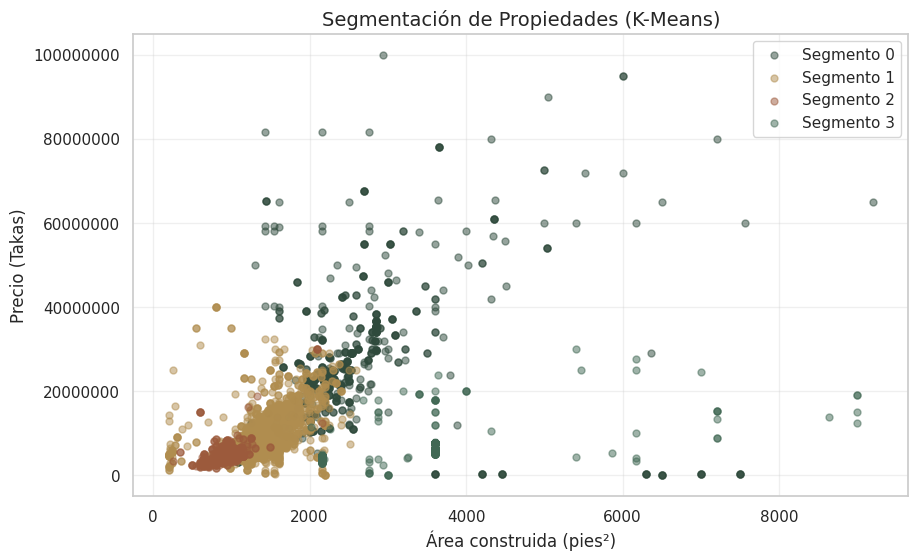

In [42]:
# Visualizamos los segmentos: Área vs Precio, coloreados por grupo
plt.figure(figsize=(10, 6))
colores = ['#2f4a3c', '#b08d4f', '#9c5a3c', '#416854']
nombres = ['Segmento 0', 'Segmento 1', 'Segmento 2', 'Segmento 3']

for seg in range(k):
    sub = df_km[df_km['Segmento'] == seg]
    plt.scatter(sub['Floor_area'], sub['Price_in_taka'],
                c=colores[seg], label=nombres[seg], alpha=0.5, s=25)

plt.title('Segmentación de Propiedades (K-Means)', fontsize=14)
plt.xlabel('Área construida (pies²)')
plt.ylabel('Precio (Takas)')
plt.legend()
plt.grid(alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Interpretación de los segmentos:** K-Means descubrió cuatro perfiles claros de vivienda en el mercado de Bangladesh, sin que le indicáramos ninguna etiqueta previa:

- **Premium:** propiedades grandes (4 hab, ~2.600 pies²) y caras (~৳28M). El segmento de lujo.
- **Estándar:** el grueso del mercado (3 hab, ~1.400 pies², ~৳9M). La vivienda típica.
- **Compactas/económicas:** pequeñas y accesibles (2 hab, ~900 pies², ~৳5M). Vivienda de entrada.
- **Amplias asequibles:** grandes en superficie pero de precio moderado (3 hab, ~3.000 pies², ~৳6,5M).

Este análisis le permite a una inmobiliaria ubicar rápidamente en qué segmento cae una propiedad nueva y orientar su estrategia de precio y de público objetivo.

## Set de Datos de Prueba

 Un pequeño conjunto de propiedades "nuevas" (que el modelo nunca vio) para comprobar cómo predice en casos reales. Creamos manualmente algunas viviendas de ejemplo y dejamos que nuestro mejor modelo (el Árbol de Decisión) prediga su rango de precio.

In [43]:
# Creamos un set de prueba con propiedades ficticias pero realistas.
# Cada fila representa una vivienda "nueva" que el modelo nunca vio,
# ordenadas de menor a mayor tamaño.
datos_prueba = pd.DataFrame({
    'Bedrooms':   [2, 3, 3, 4, 5],
    'Bathrooms':  [1, 2, 3, 3, 5],
    'Floor_no':   [3, 4, 5, 7, 9],
    'Floor_area': [650, 1100, 1600, 2200, 3500],
})

print("Set de datos de prueba (propiedades nuevas):")
print(datos_prueba.to_string(index=False))

# Para predecir necesitamos las mismas columnas que usó el modelo de clasificación.
# Partimos de la MEDIANA de cada columna (una ubicación "típica" del dataset)
# y solo cambiamos las características físicas de cada propiedad de prueba.
base = X_cat.median()
prueba_completa = pd.DataFrame([base] * len(datos_prueba)).reset_index(drop=True)
for col in ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area']:
    prueba_completa[col] = datos_prueba[col].values

# El Árbol de Decisión (clasificación) predice el rango de precio
predicciones = clf.predict(prueba_completa[X_cat.columns])

datos_prueba['Prediccion_Precio'] = predicciones
print("\nPredicciones del Árbol de Decisión sobre el set de prueba:")
print(datos_prueba.to_string(index=False))

Set de datos de prueba (propiedades nuevas):
 Bedrooms  Bathrooms  Floor_no  Floor_area
        2          1         3         650
        3          2         4        1100
        3          3         5        1600
        4          3         7        2200
        5          5         9        3500

Predicciones del Árbol de Decisión sobre el set de prueba:
 Bedrooms  Bathrooms  Floor_no  Floor_area Prediccion_Precio
        2          1         3         650              Bajo
        3          2         4        1100             Medio
        3          3         5        1600              Alto
        4          3         7        2200             Medio
        5          5         9        3500              Alto


**Justificación:** El modelo recibe cinco propiedades nuevas, ordenadas de menor a mayor tamaño, y asigna a cada una un rango de precio. Las viviendas pequeñas se clasifican como "Bajo", las intermedias como "Medio" y las grandes como "Alto", cubriendo las tres categorías. Esto confirma que el modelo aprendió la relación entre las características de una propiedad y su precio, y puede aplicarla correctamente a datos que nunca había visto. Así validamos que el modelo sirve para un uso real: estimar el rango de precio de una propiedad antes de tasarla.

In [44]:
# BLOQUE 1 — Exporto los datos a nivel de propiedad
# Esta será la tabla principal de mi dashboard. Tomo el dataset ya limpio,
# le agrego la categoría de precio y una columna de precio por m², y renombro.


df_dash = df.copy()
df_dash['Categoria_precio'] = y_cat                                  # agrego mi variable de clasificación
df_dash['Precio_por_m2'] = (df['Price_in_taka'] / df['Floor_area']).round(0)
df_dash['City'] = df_dash['City'].str.title()                       # dejo los nombres de ciudad capitalizados

# Renombro mis columnas al español
df_dash = df_dash.rename(columns={
    'Bedrooms': 'Dormitorios', 'Bathrooms': 'Banos', 'Floor_no': 'Piso',
    'Occupancy_status': 'Estado_ocupacion', 'Floor_area': 'Area_m2',
    'City': 'Ciudad', 'Location': 'Ubicacion', 'Price_in_taka': 'Precio_Takas'
})

# Guardo mi primer CSV
df_dash.to_csv('1_datos_propiedades.csv', index=False)
print("Exporté: 1_datos_propiedades.csv", df_dash.shape)


Exporté: 1_datos_propiedades.csv (5381, 10)
